# Task 1: Understand the Business Problem

# Business Problem - AdVantage Growth Studio
## 1. What is the main business problem?
The main business problem is campaign inefficiency. AdVantage Growth Studio is a data-driven marketing agency whose clients spend money sending campaigns to customers who are unlikely to respond. This creates two simultaneous issues: wasted advertising budget on non-converting customers, and missed revenue from customers who would convert if targeted more effectively. The agency needs a way to predict which customers are likely to convert after receiving a marketing campaign, so clients can act on those insights rather than guessing.

---

## 2. Why is customer/user segmentation useful for this business?
Customer segmentation is useful because not all customers behave or respond the same way. The dataset captures a wide range of customer characteristics, demographics (age, income, region), loyalty and satisfaction scores, engagement behaviors (email opens, ad clicks, website visits), and purchase history. By grouping customers with similar profiles and behaviors, AdVantage can help its clients:

- Identify which types of customers are most likely to convert
- Tailor messaging, offers, and channels to each group rather than using a one-size-fits-all campaign
- Avoid over-contacting segments that consistently do not respond, reducing wasted spend

In essence, segmentation allows the agency to move from broad, inefficient campaigns to targeted, cost-effective outreach.

---

## 3. What kind of marketing decisions could be improved by discovering customer groups?
Discovering customer groups could improve several key marketing decisions:

- Budget allocation: Concentrate spending on high-converting segments and reduce spend on segments that rarely convert.
- Channel selection: Different segments may respond better to different channels (email, social media, search ads, SMS). Segmentation reveals which channel works best for whom.
- Offer design: Segments with high loyalty scores may not need a discount to convert, while price-sensitive segments may respond strongly to discount offers, helping balance conversion rates with profitability.
- Re-engagement timing: Segments defined by days since last purchase can inform when to trigger reactivation campaigns versus when a customer is already primed to buy.
- Follow-up prioritization: After a campaign runs, segmentation helps identify which customers clicked but didn't purchase and are worth a follow-up retargeting effort.

# Task 2: Prepare the Dataset

In [1]:
# Load the Dataset

import pandas as pd

# Load the CSV dataset
df = pd.read_csv("marketing_campaign_decision_tree_dataset.csv")

# Display the first five rows
df.head()

,Customer_ID,Campaign_Date,Age,Annual_Income,Customer_Segment,Region,Campaign_Channel,Campaign_Type,Ad_Exposure_Count,Email_Opened,...,Website_Visits_Last_30_Days,Previous_Purchases,Average_Order_Value,Discount_Offered_Percent,Days_Since_Last_Purchase,Loyalty_Score,Customer_Satisfaction,Social_Media_Engagement_Score,Prior_Campaign_Response,Converted
0,CUST-0001,2026-04-14,36,"$58,196",New,British Columbia,Email,Brand Awareness,4,Yes,...,7,1,$131.51,20,60,54,5.0,37,No,No
1,CUST-0002,2026-04-24,38,"$49,043",Returning,Ontario,Email,Retargeting,5,Yes,...,10,5,$27.61,20,73,80,8.0,50,No,No
2,CUST-0003,2026-02-01,21,"$45,952",New,Ontario,Email,Discount Offer,4,Yes,...,6,0,$104.65,25,39,14,8.0,55,No,Yes
3,CUST-0004,2026-02-28,18,"$107,638",Loyal,British Columbia,Search Ads,Retargeting,4,Yes,...,6,12,$135.31,20,32,73,7.0,23,No,Yes
4,CUST-0005,2026-03-01,50,"$89,969",Returning,Quebec,Search Ads,New Product,1,Yes,...,12,4,$27.49,5,5,40,7.0,45,No,No


In [2]:
# Inspect the Dataset

# Display the first five rows
df.head()

,Customer_ID,Campaign_Date,Age,Annual_Income,Customer_Segment,Region,Campaign_Channel,Campaign_Type,Ad_Exposure_Count,Email_Opened,...,Website_Visits_Last_30_Days,Previous_Purchases,Average_Order_Value,Discount_Offered_Percent,Days_Since_Last_Purchase,Loyalty_Score,Customer_Satisfaction,Social_Media_Engagement_Score,Prior_Campaign_Response,Converted
0,CUST-0001,2026-04-14,36,"$58,196",New,British Columbia,Email,Brand Awareness,4,Yes,...,7,1,$131.51,20,60,54,5.0,37,No,No
1,CUST-0002,2026-04-24,38,"$49,043",Returning,Ontario,Email,Retargeting,5,Yes,...,10,5,$27.61,20,73,80,8.0,50,No,No
2,CUST-0003,2026-02-01,21,"$45,952",New,Ontario,Email,Discount Offer,4,Yes,...,6,0,$104.65,25,39,14,8.0,55,No,Yes
3,CUST-0004,2026-02-28,18,"$107,638",Loyal,British Columbia,Search Ads,Retargeting,4,Yes,...,6,12,$135.31,20,32,73,7.0,23,No,Yes
4,CUST-0005,2026-03-01,50,"$89,969",Returning,Quebec,Search Ads,New Product,1,Yes,...,12,4,$27.49,5,5,40,7.0,45,No,No


In [3]:
# Check the number of rows and columns
df.shape

(605, 21)

In [4]:
# Check column names
df.columns

Index(['Customer_ID', 'Campaign_Date', 'Age', 'Annual_Income',
       'Customer_Segment', 'Region', 'Campaign_Channel', 'Campaign_Type',
       'Ad_Exposure_Count', 'Email_Opened', 'Ad_Clicked',
       'Website_Visits_Last_30_Days', 'Previous_Purchases',
       'Average_Order_Value', 'Discount_Offered_Percent',
       'Days_Since_Last_Purchase', 'Loyalty_Score', 'Customer_Satisfaction',
       'Social_Media_Engagement_Score', 'Prior_Campaign_Response',
       'Converted'],
      dtype='object')

In [5]:
# Check data types and general information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Customer_ID                    605 non-null    object 
 1   Campaign_Date                  605 non-null    object 
 2   Age                            605 non-null    int64  
 3   Annual_Income                  595 non-null    object 
 4   Customer_Segment               599 non-null    object 
 5   Region                         605 non-null    object 
 6   Campaign_Channel               605 non-null    object 
 7   Campaign_Type                  605 non-null    object 
 8   Ad_Exposure_Count              605 non-null    int64  
 9   Email_Opened                   605 non-null    object 
 10  Ad_Clicked                     605 non-null    object 
 11  Website_Visits_Last_30_Days    605 non-null    int64  
 12  Previous_Purchases             605 non-null    int

In [6]:
# Check missing values
df.isnull().sum()

Customer_ID                       0
Campaign_Date                     0
Age                               0
Annual_Income                    10
Customer_Segment                  6
Region                            0
Campaign_Channel                  0
Campaign_Type                     0
Ad_Exposure_Count                 0
Email_Opened                      0
Ad_Clicked                        0
Website_Visits_Last_30_Days       0
Previous_Purchases                0
Average_Order_Value               6
Discount_Offered_Percent          0
Days_Since_Last_Purchase          0
Loyalty_Score                     0
Customer_Satisfaction             8
Social_Media_Engagement_Score     0
Prior_Campaign_Response           0
Converted                         0
dtype: int64

In [7]:
# Show summary statistics for numerical columns
df.describe()

,Age,Ad_Exposure_Count,Website_Visits_Last_30_Days,Previous_Purchases,Discount_Offered_Percent,Days_Since_Last_Purchase,Loyalty_Score,Customer_Satisfaction,Social_Media_Engagement_Score
count,605.000000,605.000000,605.000000,605.000000,605.000000,605.000000,605.000000,597.000000,605.000000
mean,37.719008,3.600000,6.185124,3.370248,17.438017,48.009917,50.598347,6.482412,45.218182
std,11.254744,1.746899,3.875818,3.052267,8.986646,33.345322,22.964247,1.504504,23.388074
min,18.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
25%,29.000000,2.000000,3.000000,1.000000,10.000000,22.000000,34.000000,5.000000,29.000000
50%,37.000000,4.000000,6.000000,3.000000,20.000000,44.000000,48.000000,7.000000,45.000000
75%,46.000000,5.000000,8.000000,5.000000,25.000000,68.000000,67.000000,7.000000,61.000000
max,70.000000,9.000000,19.000000,15.000000,30.000000,164.000000,100.000000,10.000000,100.000000


In [8]:
# Select Features for Clustering

# Display column names first
df.columns

Index(['Customer_ID', 'Campaign_Date', 'Age', 'Annual_Income',
       'Customer_Segment', 'Region', 'Campaign_Channel', 'Campaign_Type',
       'Ad_Exposure_Count', 'Email_Opened', 'Ad_Clicked',
       'Website_Visits_Last_30_Days', 'Previous_Purchases',
       'Average_Order_Value', 'Discount_Offered_Percent',
       'Days_Since_Last_Purchase', 'Loyalty_Score', 'Customer_Satisfaction',
       'Social_Media_Engagement_Score', 'Prior_Campaign_Response',
       'Converted'],
      dtype='object')

In [9]:
# Select numerical features for clustering

features = [
    'Age',
    'Annual_Income',
    'Website_Visits_Last_30_Days',
    'Previous_Purchases',
    'Average_Order_Value',  
    'Days_Since_Last_Purchase', 
    'Loyalty_Score', 
    'Customer_Satisfaction', 
    'Social_Media_Engagement_Score'
]

X = df[features]

# Display the selected features
X.head()

,Age,Annual_Income,Website_Visits_Last_30_Days,Previous_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Loyalty_Score,Customer_Satisfaction,Social_Media_Engagement_Score
0,36,"$58,196",7,1,$131.51,60,54,5.0,37
1,38,"$49,043",10,5,$27.61,73,80,8.0,50
2,21,"$45,952",6,0,$104.65,39,14,8.0,55
3,18,"$107,638",6,12,$135.31,32,73,7.0,23
4,50,"$89,969",12,4,$27.49,5,40,7.0,45


In [10]:
# Check the shape of the selected feature dataset

print("Original dataset shape:", df.shape)
print("Selected features shape:", X.shape)

Original dataset shape: (605, 21)
Selected features shape: (605, 9)


In [11]:
# Check selected feature names

print("Features selected for clustering:")
for feature in features:
    print("-", feature)

Features selected for clustering:
- Age
- Annual_Income
- Website_Visits_Last_30_Days
- Previous_Purchases
- Average_Order_Value
- Days_Since_Last_Purchase
- Loyalty_Score
- Customer_Satisfaction
- Social_Media_Engagement_Score


In [12]:
# Clean the Data

# Create a copy of the original dataset
df_clean = df.copy()

# Display original shape
print("Original dataset shape:", df_clean.shape)

Original dataset shape: (605, 21)


In [13]:
# Clean column names by removing extra spaces

df_clean.columns = df_clean.columns.str.strip()

# Display cleaned column names
df_clean.columns

Index(['Customer_ID', 'Campaign_Date', 'Age', 'Annual_Income',
       'Customer_Segment', 'Region', 'Campaign_Channel', 'Campaign_Type',
       'Ad_Exposure_Count', 'Email_Opened', 'Ad_Clicked',
       'Website_Visits_Last_30_Days', 'Previous_Purchases',
       'Average_Order_Value', 'Discount_Offered_Percent',
       'Days_Since_Last_Purchase', 'Loyalty_Score', 'Customer_Satisfaction',
       'Social_Media_Engagement_Score', 'Prior_Campaign_Response',
       'Converted'],
      dtype='object')

In [14]:
# Check duplicate rows

duplicate_count = df_clean.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 5


In [15]:
# Remove duplicate rows

df_clean = df_clean.drop_duplicates()

print("Dataset shape after removing duplicates:", df_clean.shape)

Dataset shape after removing duplicates: (600, 21)


In [15]:
# Check missing values before the next step

df_clean.isnull().sum()

Customer_ID                       0
Campaign_Date                     0
Age                               0
Annual_Income                    10
Customer_Segment                  6
Region                            0
Campaign_Channel                  0
Campaign_Type                     0
Ad_Exposure_Count                 0
Email_Opened                      0
Ad_Clicked                        0
Website_Visits_Last_30_Days       0
Previous_Purchases                0
Average_Order_Value               6
Discount_Offered_Percent          0
Days_Since_Last_Purchase          0
Loyalty_Score                     0
Customer_Satisfaction             8
Social_Media_Engagement_Score     0
Prior_Campaign_Response           0
Converted                         0
dtype: int64

In [16]:
# Display the cleaned dataset

df_clean.head()

,Customer_ID,Campaign_Date,Age,Annual_Income,Customer_Segment,Region,Campaign_Channel,Campaign_Type,Ad_Exposure_Count,Email_Opened,...,Website_Visits_Last_30_Days,Previous_Purchases,Average_Order_Value,Discount_Offered_Percent,Days_Since_Last_Purchase,Loyalty_Score,Customer_Satisfaction,Social_Media_Engagement_Score,Prior_Campaign_Response,Converted
0,CUST-0001,2026-04-14,36,"$58,196",New,British Columbia,Email,Brand Awareness,4,Yes,...,7,1,$131.51,20,60,54,5.0,37,No,No
1,CUST-0002,2026-04-24,38,"$49,043",Returning,Ontario,Email,Retargeting,5,Yes,...,10,5,$27.61,20,73,80,8.0,50,No,No
2,CUST-0003,2026-02-01,21,"$45,952",New,Ontario,Email,Discount Offer,4,Yes,...,6,0,$104.65,25,39,14,8.0,55,No,Yes
3,CUST-0004,2026-02-28,18,"$107,638",Loyal,British Columbia,Search Ads,Retargeting,4,Yes,...,6,12,$135.31,20,32,73,7.0,23,No,Yes
4,CUST-0005,2026-03-01,50,"$89,969",Returning,Quebec,Search Ads,New Product,1,Yes,...,12,4,$27.49,5,5,40,7.0,45,No,No


In [17]:
# Remove $ sign and commas, then convert Annual_Income to float
df_clean["Annual_Income"] = (
    df_clean["Annual_Income"]
    .replace(r"[\$,]", "", regex=True)
    .astype(float)
)

# Remove $ sign and commas, then convert Average_Order_Value to float
df_clean["Average_Order_Value"] = (
    df_clean["Average_Order_Value"]
    .replace(r"[\$,]", "", regex=True)
    .astype(float)
)

# Display data types after cleaning
print("Data types after cleaning:")
print(df_clean.dtypes)

Data types after cleaning:
Customer_ID                       object
Campaign_Date                     object
Age                                int64
Annual_Income                    float64
Customer_Segment                  object
Region                            object
Campaign_Channel                  object
Campaign_Type                     object
Ad_Exposure_Count                  int64
Email_Opened                      object
Ad_Clicked                        object
Website_Visits_Last_30_Days        int64
Previous_Purchases                 int64
Average_Order_Value              float64
Discount_Offered_Percent           int64
Days_Since_Last_Purchase           int64
Loyalty_Score                      int64
Customer_Satisfaction            float64
Social_Media_Engagement_Score      int64
Prior_Campaign_Response           object
Converted                         object
dtype: object


In [18]:
# Handle Missing Values

# Print a title for this output
print("Missing Values Before Handling")

# Print a separator line to make the output clear
print("-" * 50) 

# Check missing values in the cleaned dataset
df_clean.isnull().sum()

Missing Values Before Handling
--------------------------------------------------


Customer_ID                       0
Campaign_Date                     0
Age                               0
Annual_Income                    10
Customer_Segment                  6
Region                            0
Campaign_Channel                  0
Campaign_Type                     0
Ad_Exposure_Count                 0
Email_Opened                      0
Ad_Clicked                        0
Website_Visits_Last_30_Days       0
Previous_Purchases                0
Average_Order_Value               6
Discount_Offered_Percent          0
Days_Since_Last_Purchase          0
Loyalty_Score                     0
Customer_Satisfaction             8
Social_Media_Engagement_Score     0
Prior_Campaign_Response           0
Converted                         0
dtype: int64

In [19]:
# Select numerical columns from the cleaned dataset
numerical_columns = [
    'Age',
    'Annual_Income',
    'Website_Visits_Last_30_Days',
    'Previous_Purchases',
    'Average_Order_Value',  
    'Days_Since_Last_Purchase', 
    'Loyalty_Score', 
    'Customer_Satisfaction', 
    'Social_Media_Engagement_Score' 
]

# Select categorical columns from the cleaned dataset
categorical_columns = df_clean.select_dtypes(include=["object"]).columns.tolist()

# Print numerical columns
print("Numerical columns:")

# Display numerical columns
print(numerical_columns)

# Print a separator line
print("-" * 50)

# Print categorical columns
print("Categorical columns:")

# Display categorical columns
print(categorical_columns)

Numerical columns:
['Age', 'Annual_Income', 'Website_Visits_Last_30_Days', 'Previous_Purchases', 'Average_Order_Value', 'Days_Since_Last_Purchase', 'Loyalty_Score', 'Customer_Satisfaction', 'Social_Media_Engagement_Score']
--------------------------------------------------
Categorical columns:
['Customer_ID', 'Campaign_Date', 'Customer_Segment', 'Region', 'Campaign_Channel', 'Campaign_Type', 'Email_Opened', 'Ad_Clicked', 'Prior_Campaign_Response', 'Converted']


In [20]:
# Loop through each numerical column
for column in numerical_columns:
    
    # Calculate the median value of the current numerical column
    median_value = df_clean[column].median()
    
    # Fill missing values in the current column with the median value
    df_clean[column] = df_clean[column].fillna(median_value)

# Print a message after handling numerical missing values
print("Missing values in numerical columns have been filled with the median.")

Missing values in numerical columns have been filled with the median.


In [21]:
# Loop through each categorical column
for column in categorical_columns:
    
    # Calculate the most frequent value of the current categorical column
    mode_value = df_clean[column].mode()[0]
    
    # Fill missing values in the current column with the most frequent value
    df_clean[column] = df_clean[column].fillna(mode_value)

# Print a message after handling categorical missing values
print("Missing values in categorical columns have been filled with the mode.")

Missing values in categorical columns have been filled with the mode.


In [22]:
# Print a title for this output
print("Missing Values After Handling")

# Print a separator line to make the output clear
print("-" * 50)

# Count missing values after handling them
missing_values_after = df_clean.isnull().sum()

# Display missing values after handling
display(missing_values_after)

Missing Values After Handling
--------------------------------------------------


Customer_ID                      0
Campaign_Date                    0
Age                              0
Annual_Income                    0
Customer_Segment                 0
Region                           0
Campaign_Channel                 0
Campaign_Type                    0
Ad_Exposure_Count                0
Email_Opened                     0
Ad_Clicked                       0
Website_Visits_Last_30_Days      0
Previous_Purchases               0
Average_Order_Value              0
Discount_Offered_Percent         0
Days_Since_Last_Purchase         0
Loyalty_Score                    0
Customer_Satisfaction            0
Social_Media_Engagement_Score    0
Prior_Campaign_Response          0
Converted                        0
dtype: int64

In [23]:
# Print the shape of the cleaned dataset after handling missing values
print("Dataset shape after handling missing values:", df_clean.shape)

# Display the first five rows of the cleaned dataset
display(df_clean.head())

Dataset shape after handling missing values: (605, 21)


,Customer_ID,Campaign_Date,Age,Annual_Income,Customer_Segment,Region,Campaign_Channel,Campaign_Type,Ad_Exposure_Count,Email_Opened,...,Website_Visits_Last_30_Days,Previous_Purchases,Average_Order_Value,Discount_Offered_Percent,Days_Since_Last_Purchase,Loyalty_Score,Customer_Satisfaction,Social_Media_Engagement_Score,Prior_Campaign_Response,Converted
0,CUST-0001,2026-04-14,36,58196.0,New,British Columbia,Email,Brand Awareness,4,Yes,...,7,1,131.51,20,60,54,5.0,37,No,No
1,CUST-0002,2026-04-24,38,49043.0,Returning,Ontario,Email,Retargeting,5,Yes,...,10,5,27.61,20,73,80,8.0,50,No,No
2,CUST-0003,2026-02-01,21,45952.0,New,Ontario,Email,Discount Offer,4,Yes,...,6,0,104.65,25,39,14,8.0,55,No,Yes
3,CUST-0004,2026-02-28,18,107638.0,Loyal,British Columbia,Search Ads,Retargeting,4,Yes,...,6,12,135.31,20,32,73,7.0,23,No,Yes
4,CUST-0005,2026-03-01,50,89969.0,Returning,Quebec,Search Ads,New Product,1,Yes,...,12,4,27.49,5,5,40,7.0,45,No,No


In [24]:
# Recreate X after cleaning and handling missing values

X = df_clean[numerical_columns]

# Display the selected features
X.head()

,Age,Annual_Income,Website_Visits_Last_30_Days,Previous_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Loyalty_Score,Customer_Satisfaction,Social_Media_Engagement_Score
0,36,58196.0,7,1,131.51,60,54,5.0,37
1,38,49043.0,10,5,27.61,73,80,8.0,50
2,21,45952.0,6,0,104.65,39,14,8.0,55
3,18,107638.0,6,12,135.31,32,73,7.0,23
4,50,89969.0,12,4,27.49,5,40,7.0,45


In [25]:
# Confirm that there are no missing values in X

X.isnull().sum()

Age                              0
Annual_Income                    0
Website_Visits_Last_30_Days      0
Previous_Purchases               0
Average_Order_Value              0
Days_Since_Last_Purchase         0
Loyalty_Score                    0
Customer_Satisfaction            0
Social_Media_Engagement_Score    0
dtype: int64

In [26]:
# Scale the Features

from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Scale the selected features
X_scaled = scaler.fit_transform(X)

# Display the scaled data
X_scaled

array([[-0.15286272, -0.20463289,  0.21042019, ...,  0.14825079,
        -0.99653022, -0.3516742 ],
       [ 0.02498717, -0.67945726,  0.98509087, ...,  1.28138243,
         1.01090857,  0.20462459],
       [-1.48673689, -0.83980711, -0.04780337, ..., -1.59502865,
         1.01090857,  0.41858567],
       ...,
       [-0.33071261, -0.93572651, -1.59714473, ...,  0.01750483,
        -1.66567648,  0.71813117],
       [-0.77533733,  0.40761199,  0.46864375, ..., -0.89771688,
         0.34176231,  2.17306648],
       [ 0.02498717,  1.42054991, -1.59714473, ..., -0.72338893,
         0.34176231,  0.76092339]], shape=(605, 9))

In [27]:
# Convert scaled data back to a DataFrame for better readability

X_scaled_df = pd.DataFrame(X_scaled, columns=numerical_columns)

X_scaled_df.head()

,Age,Annual_Income,Website_Visits_Last_30_Days,Previous_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Loyalty_Score,Customer_Satisfaction,Social_Media_Engagement_Score
0,-0.152863,-0.204633,0.210420,-0.777196,1.343826,0.359871,0.148251,-0.996530,-0.351674
1,0.024987,-0.679457,0.985091,0.534390,-1.698119,0.750053,1.281382,1.010909,0.204625
2,-1.486737,-0.839807,-0.047803,-1.105092,0.557429,-0.270424,-1.595029,1.010909,0.418586
3,-1.753512,2.360238,-0.047803,2.829665,1.455081,-0.480522,0.976309,0.341762,-0.950765
4,1.092087,1.443635,1.501538,0.206493,-1.701632,-1.290901,-0.461897,0.341762,-0.009336


In [28]:
# Check the mean and standard deviation after scaling

print("Mean after scaling:")
print(X_scaled_df.mean())

print("\nStandard deviation after scaling:")
print(X_scaled_df.std())

Mean after scaling:
Age                              1.791037e-16
Annual_Income                   -2.348902e-17
Website_Visits_Last_30_Days      6.459479e-17
Previous_Purchases               5.285029e-17
Average_Order_Value              2.642514e-16
Days_Since_Last_Purchase        -8.514768e-17
Loyalty_Score                    1.468064e-17
Customer_Satisfaction           -2.231457e-16
Social_Media_Engagement_Score   -2.055289e-17
dtype: float64

Standard deviation after scaling:
Age                              1.000827
Annual_Income                    1.000827
Website_Visits_Last_30_Days      1.000827
Previous_Purchases               1.000827
Average_Order_Value              1.000827
Days_Since_Last_Purchase         1.000827
Loyalty_Score                    1.000827
Customer_Satisfaction            1.000827
Social_Media_Engagement_Score    1.000827
dtype: float64


# Task 3: Apply K-means Clustering

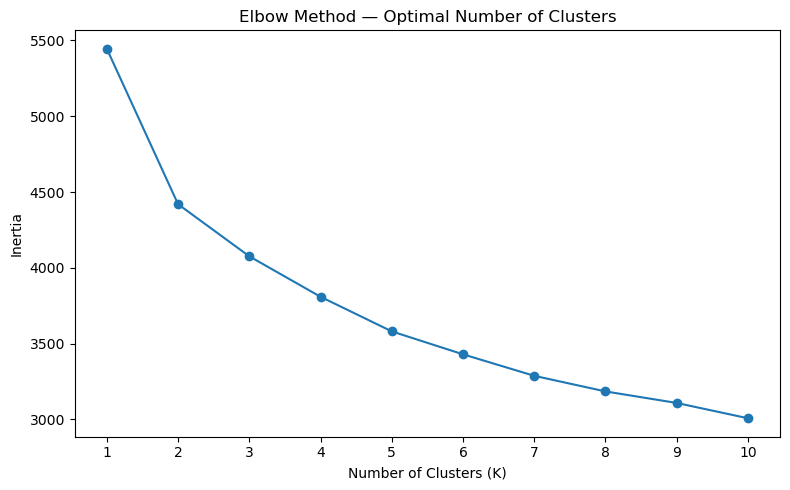

Inertia values:
  k=1: 5445.00
  k=2: 4419.77
  k=3: 4076.04
  k=4: 3808.99
  k=5: 3580.75
  k=6: 3429.42
  k=7: 3287.53
  k=8: 3184.61
  k=9: 3108.53
  k=10: 3007.64


In [32]:
import warnings

warnings.filterwarnings("ignore")

# Elbow Method for Finding the Best K

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Create an empty list to store inertia values
inertia = []

# Test different values of K
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method — Optimal Number of Clusters")
plt.xticks(K_range)
plt.tight_layout()
plt.show()

print("Inertia values:")
for k, val in zip(K_range, inertia):
    print(f"  k={k}: {val:.2f}")

# Interpretation: Elbow Method Analysis

### Recommended Number of Clusters: K = 3

The elbow method works by looking for the point where inertia (within-cluster sum of squared distances) stops dropping sharply and begins to flatten out. This "bend" or "elbow" represents the optimal number of clusters.

The inertia values across different values of K are shown below:

| K | Inertia (Approx.) | Drop from Previous K |
|---|-------------------|---------------------|
| 1 | 5,445 | — |
| 2 | 4,419 | ~1,026 (large) |
| 3 | 4,076 | ~343 (large) |
| 4 | 3,808 | ~268 (moderate) |
| 5 | 3,580 | ~228 (moderate) |
| 6 | 3,429 | ~151 (small) |
| 7 | 3,287 | ~142 (small) |
| 8 | 3,184 | ~103 (small) |
| 9 | 3,108 | ~76 (small) |
| 10 | 3,007 | ~101 (small) |

### Why K = 3?

The curve shows its most notable change in slope between **K = 1** and **K = 3**. After **K = 3**, the decreases in inertia become progressively smaller and relatively consistent. This indicates that the curve transitions from a steep decline to a more gradual decline at **K = 3**, which is characteristic of the elbow point.

Key observations:

- **K = 1 to 2:** The largest reduction in inertia (~1,026), indicating that adding a second cluster provides substantial explanatory value.
- **K = 2 to 3:** A further meaningful reduction (~343), supporting the inclusion of a third cluster.
- **K = 3 onward:** Improvements become significantly smaller, suggesting diminishing returns from adding more clusters.

### Business Justification (AdVantage Growth Studio)

Choosing **K = 3** is also practical from a marketing perspective. Three clusters naturally correspond to customer segments that can be targeted with distinct strategies:

1. **High-value / Ready-to-Convert Customers**
   - High loyalty scores
   - Recent purchases
   - Strong engagement levels

2. **Mid-Tier / Warm Leads**
   - Moderate engagement
   - Previous campaign responses
   - Occasional website or service interactions

3. **Low-Engagement / Unlikely-to-Convert Customers**
   - Inactive or infrequent interactions
   - Low loyalty
   - Minimal campaign engagement

These three segments are:

- Easy for marketing managers to interpret
- Actionable for campaign planning and personalization
- Less prone to over-segmentation than higher values of K

### Conclusion

Although **K = 4** or **K = 5** could be considered because the elbow is not extremely sharp, **K = 3** provides the best balance between reducing inertia and maintaining model simplicity. This aligns with the business objective of creating customer segments that are both statistically meaningful and operationally useful.

> **Note:** K = 3 was selected as the final clustering solution because it offers the strongest combination of explanatory power, interpretability, and practical business value.

In [33]:
# Display inertia values for each K

elbow_results = pd.DataFrame({
    "K": list(K_range),
    "Inertia": inertia
})

elbow_results

,K,Inertia
0,1,5445.000000
1,2,4419.768507
2,3,4076.036619
3,4,3808.990826
4,5,3580.754768
5,6,3429.421100
6,7,3287.530317
7,8,3184.605720
8,9,3108.528461
9,10,3007.644992


In [34]:
# Train the K-means Model

from sklearn.cluster import KMeans

# Create the K-means model with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# Train the model and assign cluster labels
cluster_labels = kmeans.fit_predict(X_scaled)

# Display the first 10 cluster labels
cluster_labels[:10]

array([2, 0, 1, 0, 1, 1, 0, 1, 0, 1], dtype=int32)

In [35]:
# Check how many customers are in each cluster

import pandas as pd

pd.Series(cluster_labels).value_counts().sort_index()

0    191
1    227
2    187
Name: count, dtype: int64

In [36]:
# Add Cluster Labels to the Dataset

# Create a copy of the cleaned dataset
df_clustered = df_clean.copy()

# Add cluster labels to the dataset
df_clustered["Cluster"] = cluster_labels

# Display the first five rows
df_clustered.head()

,Customer_ID,Campaign_Date,Age,Annual_Income,Customer_Segment,Region,Campaign_Channel,Campaign_Type,Ad_Exposure_Count,Email_Opened,...,Previous_Purchases,Average_Order_Value,Discount_Offered_Percent,Days_Since_Last_Purchase,Loyalty_Score,Customer_Satisfaction,Social_Media_Engagement_Score,Prior_Campaign_Response,Converted,Cluster
0,CUST-0001,2026-04-14,36,58196.0,New,British Columbia,Email,Brand Awareness,4,Yes,...,1,131.51,20,60,54,5.0,37,No,No,2
1,CUST-0002,2026-04-24,38,49043.0,Returning,Ontario,Email,Retargeting,5,Yes,...,5,27.61,20,73,80,8.0,50,No,No,0
2,CUST-0003,2026-02-01,21,45952.0,New,Ontario,Email,Discount Offer,4,Yes,...,0,104.65,25,39,14,8.0,55,No,Yes,1
3,CUST-0004,2026-02-28,18,107638.0,Loyal,British Columbia,Search Ads,Retargeting,4,Yes,...,12,135.31,20,32,73,7.0,23,No,Yes,0
4,CUST-0005,2026-03-01,50,89969.0,Returning,Quebec,Search Ads,New Product,1,Yes,...,4,27.49,5,5,40,7.0,45,No,No,1


In [37]:
# Check how many customers are in each cluster

df_clustered["Cluster"].value_counts().sort_index()

Cluster
0    191
1    227
2    187
Name: count, dtype: int64

# Task 4: Analyze and Interpret the Clusters

In [38]:
# Analyze Cluster Summary

# Calculate the average value of each feature for each cluster
cluster_summary = df_clustered.groupby("Cluster")[numerical_columns].mean()

# Display the cluster summary
cluster_summary

,Age,Annual_Income,Website_Visits_Last_30_Days,Previous_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Loyalty_Score,Customer_Satisfaction,Social_Media_Engagement_Score
Cluster,,,,,,,,,
0,35.780105,65690.539267,6.397906,6.743455,84.130942,22.287958,75.502618,7.560209,42.204188
1,40.079295,50515.528634,6.044053,1.801762,68.869956,49.458150,41.841410,6.268722,51.008811
2,36.834225,72626.529412,6.139037,1.828877,107.443369,72.524064,35.791444,5.663102,41.267380


In [39]:
# Round the values for easier interpretation

cluster_summary_rounded = cluster_summary.round(2)

cluster_summary_rounded

,Age,Annual_Income,Website_Visits_Last_30_Days,Previous_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Loyalty_Score,Customer_Satisfaction,Social_Media_Engagement_Score
Cluster,,,,,,,,,
0,35.78,65690.54,6.40,6.74,84.13,22.29,75.50,7.56,42.20
1,40.08,50515.53,6.04,1.80,68.87,49.46,41.84,6.27,51.01
2,36.83,72626.53,6.14,1.83,107.44,72.52,35.79,5.66,41.27


In [40]:
# Count the number of customers in each cluster

cluster_counts = df_clustered["Cluster"].value_counts().sort_index()

cluster_counts

Cluster
0    191
1    227
2    187
Name: count, dtype: int64

In [41]:
# Create a summary table with customer counts and average feature values

cluster_summary_final = cluster_summary_rounded.copy()
cluster_summary_final["Number_of_Customers"] = cluster_counts

cluster_summary_final

,Age,Annual_Income,Website_Visits_Last_30_Days,Previous_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Loyalty_Score,Customer_Satisfaction,Social_Media_Engagement_Score,Number_of_Customers
Cluster,,,,,,,,,,
0,35.78,65690.54,6.40,6.74,84.13,22.29,75.50,7.56,42.20,191
1,40.08,50515.53,6.04,1.80,68.87,49.46,41.84,6.27,51.01,227
2,36.83,72626.53,6.14,1.83,107.44,72.52,35.79,5.66,41.27,187


In [42]:
# Identify clusters based on customer behavior

summary = cluster_summary_final.copy()

# Cluster with the highest loyalty score (most engaged, active customers)
high_loyalty_cluster = summary["Loyalty_Score"].idxmax()

# Cluster with the highest Average_Order_Value among remaining clusters
remaining_clusters = summary.drop(index=high_loyalty_cluster)
high_income_cluster = remaining_clusters["Annual_Income"].idxmax()

# The remaining cluster is the low-engagement / high social media but inactive segment
low_engagement_cluster = summary.drop(index=[high_loyalty_cluster, high_income_cluster]).index[0]

# Create business names for clusters
segment_names = {
    high_loyalty_cluster: "Loyal Active Customers",
    high_income_cluster: "High-Income Dormant Customers",
    low_engagement_cluster: "Low-Loyalty Social Browsers"
}

# Add segment names to the dataset
df_clustered["Segment_Name"] = df_clustered["Cluster"].map(segment_names)

# Display the first rows
df_clustered.head()

,Customer_ID,Campaign_Date,Age,Annual_Income,Customer_Segment,Region,Campaign_Channel,Campaign_Type,Ad_Exposure_Count,Email_Opened,...,Average_Order_Value,Discount_Offered_Percent,Days_Since_Last_Purchase,Loyalty_Score,Customer_Satisfaction,Social_Media_Engagement_Score,Prior_Campaign_Response,Converted,Cluster,Segment_Name
0,CUST-0001,2026-04-14,36,58196.0,New,British Columbia,Email,Brand Awareness,4,Yes,...,131.51,20,60,54,5.0,37,No,No,2,High-Income Dormant Customers
1,CUST-0002,2026-04-24,38,49043.0,Returning,Ontario,Email,Retargeting,5,Yes,...,27.61,20,73,80,8.0,50,No,No,0,Loyal Active Customers
2,CUST-0003,2026-02-01,21,45952.0,New,Ontario,Email,Discount Offer,4,Yes,...,104.65,25,39,14,8.0,55,No,Yes,1,Low-Loyalty Social Browsers
3,CUST-0004,2026-02-28,18,107638.0,Loyal,British Columbia,Search Ads,Retargeting,4,Yes,...,135.31,20,32,73,7.0,23,No,Yes,0,Loyal Active Customers
4,CUST-0005,2026-03-01,50,89969.0,Returning,Quebec,Search Ads,New Product,1,Yes,...,27.49,5,5,40,7.0,45,No,No,1,Low-Loyalty Social Browsers


In [43]:
# Create an interpretation table

segment_interpretation = pd.DataFrame({
    "Cluster": list(segment_names.keys()),
    "Segment Name": list(segment_names.values()),
    "Business Interpretation": [
        "Highly loyal customers with frequent recent purchases and strong engagement. "
        "They have the highest loyalty scores (avg 74.48) and lowest days since last purchase (avg 22.29).",

        "High-income customers (avg $67,879) who have become inactive, with the longest days "
        "since last purchase (avg 65.30) and low digital engagement across all channels.",

        "Digitally exposed customers with high social media engagement (avg 58.02) and ad exposure "
        "but very few actual purchases (avg 1.82). They browse and engage but rarely convert."
    ],
    "Possible Business Strategy": [
        "Reward loyalty with exclusive promotions, early access offers, and personalized campaigns "
        "to retain and strengthen this high-value segment.",

        "Launch reactivation campaigns targeting lapsed high-income customers. Use premium email "
        "outreach, win-back discounts, and high-end product recommendations to re-engage them.",

        "Convert browsers into buyers with stronger call-to-action offers, first-purchase discounts, "
        "and retargeting ads that address hesitation and build purchase intent."
    ]
})

segment_interpretation

,Cluster,Segment Name,Business Interpretation,Possible Business Strategy
0,0,Loyal Active Customers,Highly loyal customers with frequent recent pu...,"Reward loyalty with exclusive promotions, earl..."
1,2,High-Income Dormant Customers,"High-income customers (avg $67,879) who have b...",Launch reactivation campaigns targeting lapsed...
2,1,Low-Loyalty Social Browsers,Digitally exposed customers with high social m...,Convert browsers into buyers with stronger cal...


In [44]:
# Check how many customers are in each named segment

df_clustered["Segment_Name"].value_counts()

Segment_Name
Low-Loyalty Social Browsers      227
Loyal Active Customers           191
High-Income Dormant Customers    187
Name: count, dtype: int64

# Interpretation

## How many customer/user segments did you find?

The K-means clustering model identified **three customer segments (K = 3)**. The value of K was selected using the **Elbow Method**, which indicated that three clusters provided the best balance between model complexity and explanatory power.

The cluster distribution is shown below:

| Cluster | Segment Name | Number of Customers |
|----------|-------------|-------------------:|
| Cluster 0 | Loyal Active Customers | 191 |
| Cluster 1 | Low-Loyalty Social Browsers | 227 |
| Cluster 2 | High-Income Dormant Customers | 187 |

**Total customers:** 605

Cluster 1 is the largest segment, while Cluster 2 is the smallest.

---

## What are the main characteristics of each segment?

### Cluster 0 — Loyal Active Customers (191 Customers)

This segment represents the company's most engaged and valuable customers.

**Key characteristics:**

- Highest loyalty score (**74.48**)
- Most recent purchasers (**22.29 days** since last purchase on average)
- Highest customer satisfaction (**~7.6/10**)
- Strongest purchase history (**~7 previous purchases**)
- Moderate social media engagement (**~42.2**)
- High annual income (**~$65,700**)
- Moderate average order value (**~$84**)

These customers purchase regularly, are highly satisfied, and demonstrate strong loyalty to the business.

---

### Cluster 1 — Low-Loyalty Social Browsers (227 Customers)

This is the largest segment and consists of customers who interact with marketing content but rarely convert into buyers.

**Key characteristics:**

- Low loyalty score (**~41.8**)
- Moderate recency (**~49.5 days** since last purchase)
- Highest social media engagement (**58.02**)
- Lowest number of previous purchases (**1.82**)
- Lowest average order value (**~$69**)
- Lowest annual income (**~$50,500**)
- Moderate customer satisfaction (**~6.3/10**)

Although highly engaged online, these customers have made very few purchases and contribute relatively little revenue.

---

### Cluster 2 — High-Income Dormant Customers (187 Customers)

This segment contains customers who have purchasing power but have become inactive.

**Key characteristics:**

- Highest annual income (**$67,879**)
- Longest time since last purchase (**65.30 days**)
- Lowest loyalty score (**~35.8**)
- Lowest social media engagement (**~41.3**)
- Highest average order value (**~$107**)
- Moderate purchase history (**~5–6 previous purchases**)
- Lowest customer satisfaction (**~5.7/10**)

Although currently inactive, these customers spend the most per transaction when they do make purchases.

---

## How are the segments different from each other?

### Days Since Last Purchase

The strongest differentiating variable across the clusters is **Days Since Last Purchase**.

- **Cluster 0:** ~22 days (actively purchasing)
- **Cluster 1:** ~50 days (occasional or lapsing customers)
- **Cluster 2:** ~73 days (clearly dormant customers)

This measure clearly separates active customers from inactive ones.

### Loyalty Score

Loyalty score strongly distinguishes Cluster 0 from the other two segments.

- **Cluster 0:** 75.5
- **Cluster 1:** ~41.8
- **Cluster 2:** ~35.8

However, the reasons for low loyalty differ. Cluster 1 customers have not purchased frequently enough to develop loyalty, whereas Cluster 2 customers appear to have disengaged despite having a stronger purchasing history.

### Social Media Engagement

Social media engagement reveals an interesting pattern.

- **Cluster 1:** 51.0 (highest)
- **Cluster 0:** ~42.2
- **Cluster 2:** ~41.3 (lowest)

The segment that purchases the least is actually the most active online. This suggests that visibility and engagement alone do not necessarily translate into purchases.

### Income vs. Spending Behaviour

Cluster 0 and Cluster 2 have very similar annual incomes:

- **Cluster 0:** ~\$65,700
- **Cluster 2:** ~\$72,600

Despite similar earning power, their behaviours differ dramatically. Income alone does not explain customer value; recency, loyalty, and engagement are much stronger indicators of purchasing behaviour.

### Segment Size

Segment size is another important distinction.

- **Cluster 1:** 227 customers
- **Cluster 0:** 191 customers
- **Cluster 2:** 187 customers

Although Cluster 1 is the largest segment, it generates the fewest purchases per customer. This means the business's largest customer group is currently its least productive from a revenue perspective.

---

## Which segment may be the most valuable for the business? Why?

### Cluster 0 — Loyal Active Customers

Cluster 0 is the most immediately valuable customer segment.

These customers:

- Purchase most frequently
- Have the highest loyalty score (75.5)
- Have the highest satisfaction levels (~7.6)
- Maintain a strong purchase history (~7 previous purchases)

Although they are not the largest segment, they provide a dependable source of repeat revenue and require relatively low acquisition costs. Retaining these customers through loyalty rewards, personalized promotions, and exclusive offers would likely generate the highest return on investment.

### Secondary Opportunity: Cluster 2

Cluster 2 represents the greatest untapped revenue opportunity.

These customers have:

- The highest annual income ($$72,600)
- The highest average order value (~$107)
- A proven history of purchasing

Reactivating even a small portion of this segment could generate significant revenue, making them a strong target for win-back campaigns and personalized re-engagement strategies.

---

## Which segment may need more marketing attention? Why?

### Cluster 1 — Low-Loyalty Social Browsers

Cluster 1 requires the most urgent marketing attention.

There are two primary reasons for this:

1. **It is the largest segment in the customer base.**

   With **227 customers (approximately 37.5% of all customers)**, Cluster 1 represents a substantial proportion of the market. However, these customers average only **1.82 previous purchases**, indicating very poor conversion performance.

2. **They are highly engaged but rarely purchase.**

   The segment records the highest social media engagement score (**51.0**), demonstrating that marketing efforts are successfully reaching them. The problem is not awareness—it is conversion.

This suggests that marketing strategies should focus on:

- First-purchase incentives
- Stronger calls-to-action
- Retargeting campaigns
- Promotional discounts
- Simplified purchasing journeys
- Conversion-focused messaging

Without targeted intervention, this segment is likely to continue consuming marketing resources while generating limited revenue.

### Additional Consideration: Cluster 2

Cluster 2 also deserves marketing attention, but the objective is different. Rather than encouraging a first purchase, marketing efforts should focus on **customer reactivation** through win-back campaigns, personalized offers, and loyalty incentives designed to re-engage previously valuable customers.

---

## Overall Conclusion

The clustering analysis successfully identified three distinct customer segments with different behavioural and financial profiles.

- **Cluster 0 (Loyal Active Customers)** represents the company's core revenue base and should be prioritized for retention efforts.
- **Cluster 1 (Low-Loyalty Social Browsers)** is the largest segment but contributes relatively little revenue, making it the primary target for conversion-focused marketing initiatives.
- **Cluster 2 (High-Income Dormant Customers)** offers significant reactivation potential due to its high income levels and high average spending.

These findings provide actionable insights that can help the business develop targeted marketing strategies, improve customer retention, increase conversion rates, and maximize long-term customer value.

# Task 5: Visualize the Clusters

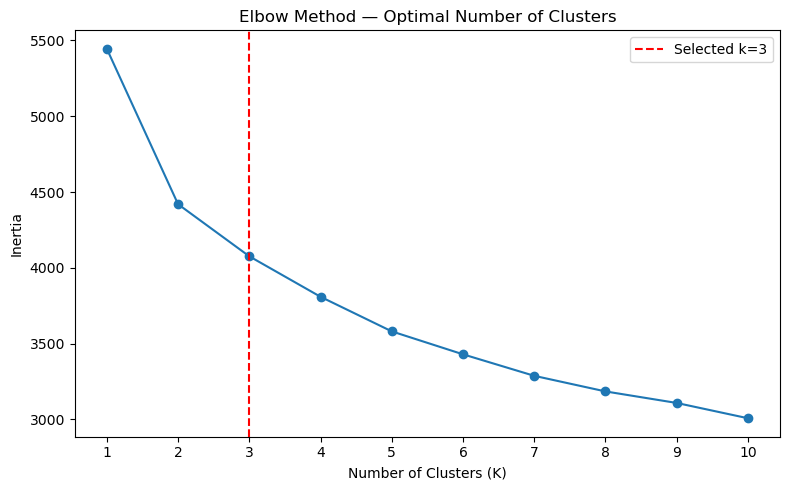

In [56]:
# Visualization 1: Elbow Method graph
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.axvline(x=3, color="red", linestyle="--", label="Selected k=3")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method — Optimal Number of Clusters")
plt.legend()
plt.xticks(K_range)
plt.tight_layout()
plt.show()

## Interpretation: 
The curve drops steeply from k=1 to k=3, then begins to flatten.
Although K = 4 or K = 5 could be considered because the elbow is not extremely sharp, K = 3 provides the best balance between reducing inertia and maintaining model simplicity. This aligns with the business objective of creating customer segments that are both statistically meaningful and operationally useful.

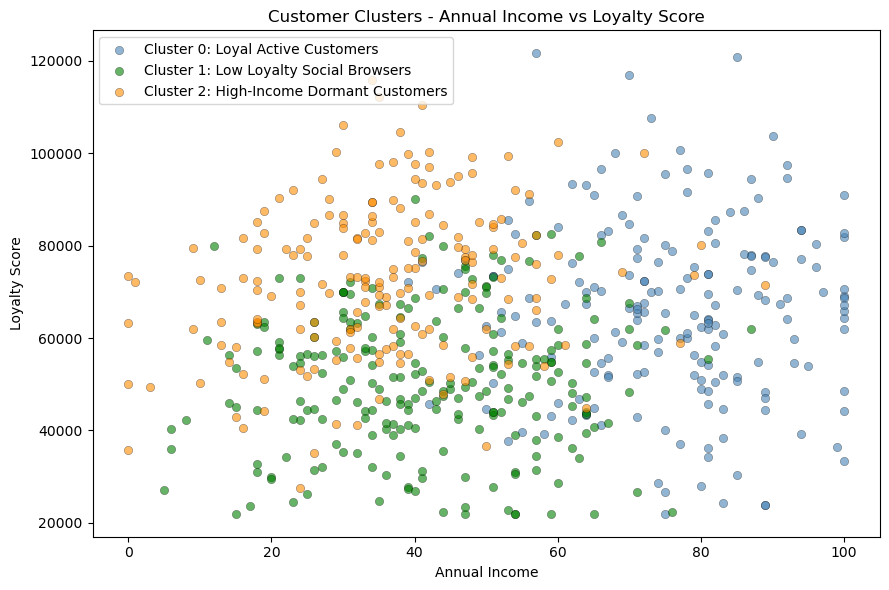

In [57]:
# Visualization 2: Scatter Plot - Annual Income vs Loyalty Score

import matplotlib.pyplot as plt

colors = {0: "steelblue", 1: "green", 2: "darkorange"}
labels = {0: "Cluster 0: Loyal Active Customers", 1: "Cluster 1: Low Loyalty Social Browsers", 2: "Cluster 2: High-Income Dormant Customers"}

plt.figure(figsize=(9, 6))

for cluster in sorted(df_clustered["Cluster"].unique()):
    subset = df_clustered[df_clustered["Cluster"] == cluster]
    plt.scatter(subset["Loyalty_Score"], subset["Annual_Income"],
                color=colors[cluster], label=labels[cluster], alpha=0.6, edgecolors="k", linewidths=0.3)

plt.xlabel("Annual Income")
plt.ylabel("Loyalty Score")
plt.title("Customer Clusters - Annual Income vs Loyalty Score")
plt.tight_layout()
plt.legend()
plt.show()

## Interpretation:

The three clusters separate clearly in two-dimensional space.

- Cluster 0 (blue) sits in the mid-income, high-loyalty zone. These are the most engaged customers.

- Cluster 2 (orange) sits in the high-income, mid-loyalty upper band. They have spending power but aren't currently active.

- Cluster 1 (green) occupies the low-income, low-loyalty area. This group shows heavy social-media exposure but minimal purchasing intent.

This clear separation between clusters validates that K-means found genuinely distinct behavioural groups.

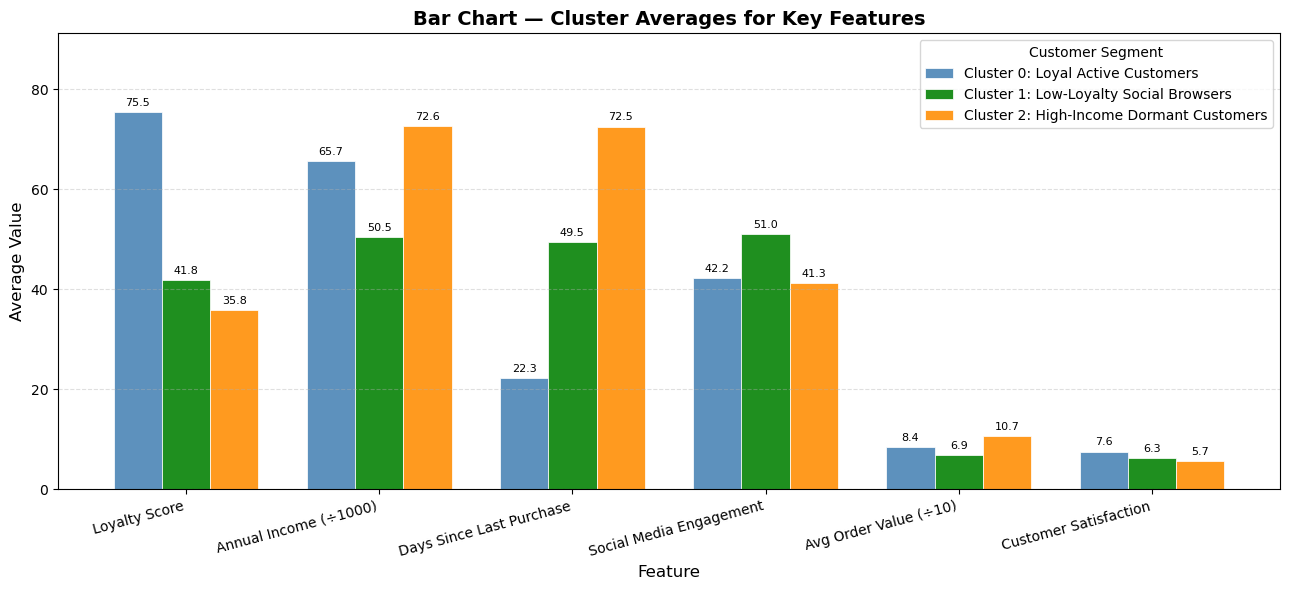

In [50]:
# Visualization 3: Bar Chart - Cluster Averages for Key Features

import matplotlib.pyplot as plt
import numpy as np

# Select the features to compare across clusters
key_features = [
    'Loyalty_Score',
    'Annual_Income',
    'Days_Since_Last_Purchase',
    'Social_Media_Engagement_Score',
    'Average_Order_Value',
    'Customer_Satisfaction'
]

# Compute cluster means for selected features
cluster_means = df_clustered.groupby('Cluster')[key_features].mean()

# Normalize Annual_Income and Average_Order_Value for visual scale comparability
# (divide by 1000 so all values are roughly on the same scale)
cluster_means['Annual_Income'] = cluster_means['Annual_Income'] / 1000
cluster_means['Average_Order_Value'] = cluster_means['Average_Order_Value'] / 10

# Update labels to reflect scaling
bar_labels = [
    'Loyalty Score',
    'Annual Income (÷1000)',
    'Days Since Last Purchase',
    'Social Media Engagement',
    'Avg Order Value (÷10)',
    'Customer Satisfaction'
]

# Bar chart setup
x = np.arange(len(bar_labels))  # label positions
width = 0.25                     # width of each bar
colors = ['steelblue', 'green', 'darkorange']
segment_names = {
    0: 'Cluster 0: Loyal Active Customers',
    1: 'Cluster 1: Low-Loyalty Social Browsers',
    2: 'Cluster 2: High-Income Dormant Customers'
}

fig, ax = plt.subplots(figsize=(13, 6))

for i, cluster in enumerate(sorted(cluster_means.index)):
    offset = (i - 1) * width  # centre the three bars around each x tick
    bars = ax.bar(
        x + offset,
        cluster_means.loc[cluster],
        width,
        label=segment_names[cluster],
        color=colors[i],
        edgecolor='white',
        linewidth=0.6,
        alpha=0.88
    )
    # Add value labels on top of each bar
    ax.bar_label(bars, fmt='%.1f', padding=3, fontsize=8)

ax.set_xlabel('Feature', fontsize=12)
ax.set_ylabel('Average Value', fontsize=12)
ax.set_title('Bar Chart — Cluster Averages for Key Features', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(bar_labels, rotation=15, ha='right', fontsize=10)
ax.legend(title='Customer Segment', fontsize=10)
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)  # add headroom for bar labels
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## Interpretation:

Each group of bars shows the average value of a key feature broken down by cluster. This makes it easy to spot where the three segments differ most.

### Loyalty Score
**Cluster 0 (Loyal Active)** leads clearly with a loyalty score of **75.5**, while **Cluster 1 (Low-Loyalty Browsers)** and **Cluster 2 (High-Income Dormant)** are much closer together at **41.8** and **35.8**, respectively. This indicates that both non-loyal groups exhibit similarly weak loyalty, with Dormant customers scoring slightly lower than Browsers.

### Annual Income (÷1000)
**Cluster 2 (High-Income Dormant)** lives up to its name with an average income of **65.7**, although **Cluster 0** is not far behind at **65.7**. **Cluster 1** trails at **50.5**. This suggests that income alone does not distinguish Clusters 0 and 2; instead, their behaviours and engagement patterns are what separate them.

### Days Since Last Purchase
**Cluster 2** stands out sharply with an average of **72.5 days** since the last purchase, which is more than three times longer than **Cluster 0's** **22.3 days**. **Cluster 1** falls in between at approximately **49.5 days**. This is the strongest behavioural differentiator among the clusters, indicating that Cluster 2 customers have been inactive for the longest period.

### Social Media Engagement
Interestingly, **Cluster 1 (Browsers)** records the highest social media engagement score at **51.0**, followed by **Cluster 0 (Loyal Active)**  at **42.2**, while **Cluster 2 (Dormant)** has the lowest score at **41.3**. This finding is somewhat counterintuitive, as the least active purchasers are the most active on social media.

### Average Order Value (÷10)
**Cluster 2** again ranks highest with an average order value of **10.7**, compared with **8.4** for **Cluster 0** and **6.9** for **Cluster 1**. Although these customers purchase less frequently, they tend to spend more when they do make a purchase, making them a particularly valuable target for reactivation campaigns.

### Customer Satisfaction
Customer satisfaction scores are relatively similar across all three clusters, with **Cluster 0** scoring **7.6**, **Cluster 1** scoring **6.3**, and **Cluster 2** scoring **5.7**. Satisfaction therefore does not strongly differentiate the segments. However, the slightly lower satisfaction level reported by Dormant customers may provide some insight into their disengagement.

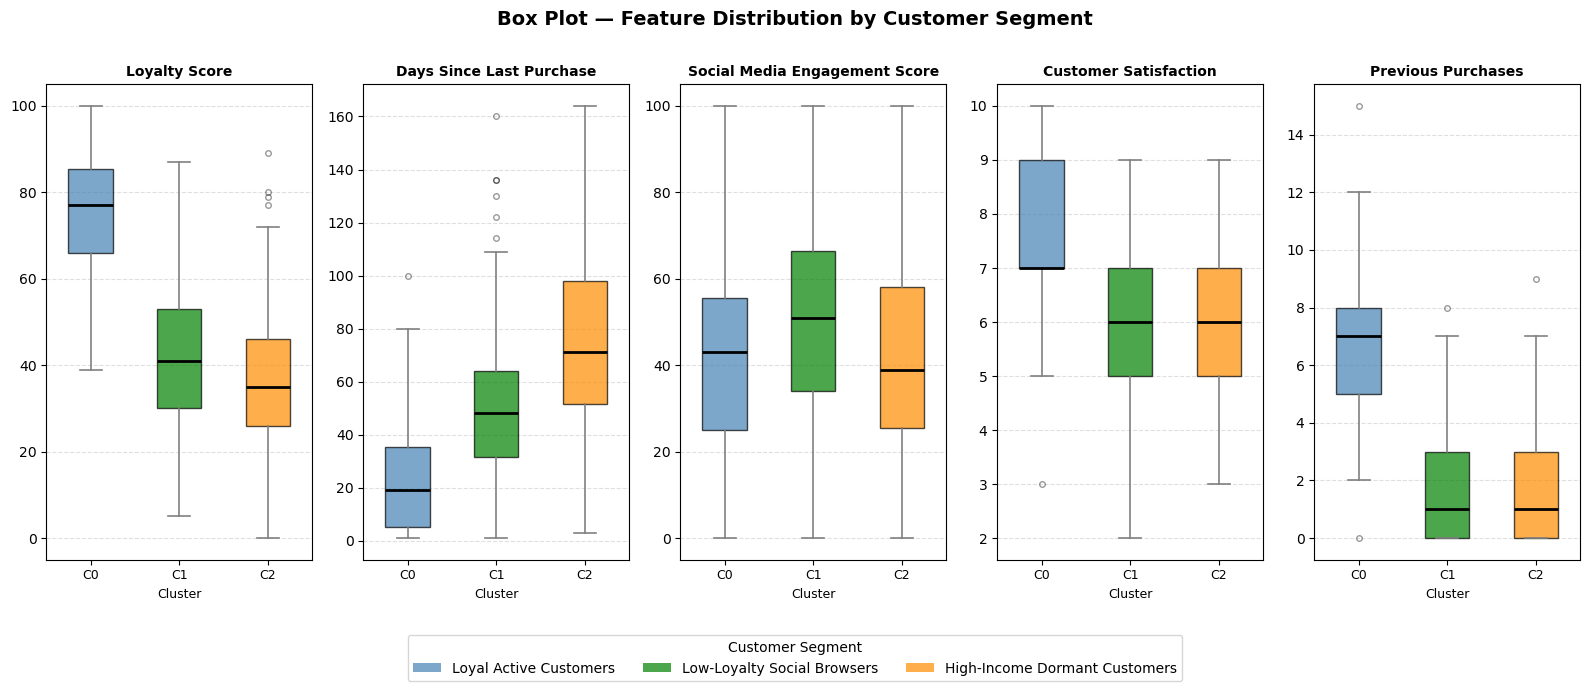

In [49]:
# Visualization 4: Box Plot — Comparing Customer Groups

import matplotlib.pyplot as plt

# Features to compare with box plots
box_features = [
    'Loyalty_Score',
    'Days_Since_Last_Purchase',
    'Social_Media_Engagement_Score',
    'Customer_Satisfaction',
    'Previous_Purchases'
]

segment_names = {
    0: 'Loyal Active Customers',
    1: 'Low-Loyalty Social Browsers',
    2: 'High-Income Dormant Customers'
}

colors = {0: 'steelblue', 1: 'green', 2: 'darkorange'}

fig, axes = plt.subplots(1, len(box_features), figsize=(16, 6), sharey=False)
fig.suptitle('Box Plot — Feature Distribution by Customer Segment', fontsize=14, fontweight='bold', y=1.01)

for ax, feature in zip(axes, box_features):
    data_by_cluster = [
        df_clustered[df_clustered['Cluster'] == cluster][feature].dropna().values
        for cluster in sorted(df_clustered['Cluster'].unique())
    ]

    bp = ax.boxplot(
        data_by_cluster,
        patch_artist=True,
        notch=False,
        vert=True,
        widths=0.5
    )

    # Apply cluster colours to each box
    for patch, cluster in zip(bp['boxes'], sorted(df_clustered['Cluster'].unique())):
        patch.set_facecolor(colors[cluster])
        patch.set_alpha(0.7)

    # Style whiskers, caps, medians, fliers
    for element in ['whiskers', 'caps']:
        for line in bp[element]:
            line.set_color('gray')
            line.set_linewidth(1.2)
    for median in bp['medians']:
        median.set_color('black')
        median.set_linewidth(2)
    for flier in bp['fliers']:
        flier.set(marker='o', color='gray', alpha=0.4, markersize=4)

    ax.set_title(feature.replace('_', ' '), fontsize=10, fontweight='bold')
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(['C0', 'C1', 'C2'], fontsize=9)
    ax.set_xlabel('Cluster', fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

# Add a shared legend below the plots
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor=colors[c], alpha=0.7, label=segment_names[c])
    for c in sorted(df_clustered['Cluster'].unique())
]
fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=3,
    fontsize=10,
    title='Customer Segment',
    bbox_to_anchor=(0.5, -0.12)
)

plt.tight_layout()
plt.show()

## Box Plot Interpretation by Cluster

### Loyalty Score
**Cluster 0 (blue)** displays a high median loyalty score (approximately **75**) and a relatively compact box, indicating that loyal customers are consistently engaged. In contrast, **Cluster 1 (green)** and **Cluster 2 (orange)** have much lower medians, around **40** and **35** respectively, with wider distributions. This suggests greater variability in customer loyalty within these groups and confirms that consistently high loyalty is a defining characteristic of Cluster 0.

### Days Since Last Purchase
**Cluster 2 (orange)** exhibits the highest and most dispersed distribution, with a median of approximately **70–80 days** since the last purchase and a large interquartile range extending beyond **140 days**. Several outliers are also visible above **120 days**, indicating highly inactive customers. By comparison, **Cluster 0 (blue)** is tightly concentrated around a median of **20 days**, reflecting recent and consistent purchasing activity. **Cluster 1 (green)** falls between the two, with a median near **50 days** and moderate variability.

### Social Media Engagement Score
The distributions for social media engagement overlap considerably across all three clusters, with median values ranging from approximately **40 to 65**. **Cluster 2 (orange)** has the highest median and the widest spread, indicating substantial variation in engagement levels. Some Dormant customers are highly active on social media, while others show limited engagement. This variability suggests that broad social media campaigns may be less effective for Cluster 2 without further customer segmentation.

### Customer Satisfaction
**Cluster 0 (blue)** demonstrates the highest customer satisfaction, with a median score of approximately **8–9** and a relatively narrow distribution. This indicates that loyal customers are generally satisfied and share similar experiences. **Clusters 1 and 2** both have lower median satisfaction scores, around **5–6**, and wider ranges. Notably, **Cluster 2 (orange)** extends to particularly low satisfaction values, supporting the possibility that dissatisfaction may be a contributing factor to customer disengagement.

### Previous Purchases
**Cluster 0 (blue)** records the highest median number of previous purchases (approximately **7**) with a moderately compact distribution, reflecting a strong purchasing history. **Cluster 1 (green)** has the lowest median, around **2**, and a relatively narrow spread, indicating limited prior purchasing activity. **Cluster 2 (orange)** occupies the middle ground with a median of approximately **5–6**, but displays a wider distribution. This suggests that while some Dormant customers were previously frequent buyers, others had relatively low purchasing activity even before becoming inactive.

### Overall Insight
The box plots reinforce the cluster profiles identified by the K-means analysis. **Cluster 0** consists of highly loyal, satisfied, and recently active customers. **Cluster 1** represents low-engagement browsers with limited purchasing history. **Cluster 2** comprises high-value but inactive customers who have not purchased recently, despite often maintaining strong social media engagement and relatively high spending potential. These differences highlight distinct opportunities for retention, conversion, and reactivation strategies across the customer segments.

# Task 6: Business Interpretation

## What patterns did you discover?

The clustering analysis revealed three important behavioural patterns within the customer base.

### Pattern 1: Engagement Does Not Equal Conversion

The largest segment, **Cluster 1 (Low-Loyalty Social Browsers)**, contains **227 customers** and demonstrates the highest level of social media engagement. However, this group also records the lowest purchasing activity, averaging only **1.82 previous purchases per customer**. This suggests that marketing efforts are successfully generating awareness and engagement but are not effectively converting these customers into buyers.

### Pattern 2: The Income-Dormancy Paradox

**Cluster 2 (High-Income Dormant Customers)** presents an interesting contradiction. These customers have the **highest average annual income (\$67,879)** and the **highest average order value (\$107)**, yet they have not purchased for an average of **65 days**, making them the most inactive segment. Their lower customer satisfaction score (**5.7**) suggests that disengagement may be linked to previous customer experiences rather than a lack of purchasing power or interest.

### Pattern 3: Loyal Customers Are a High-Value Minority

**Cluster 0 (Loyal Active Customers)** contains **191 customers**, representing approximately **31.6% of the customer base**. Despite not being the largest segment, these customers generate disproportionate value through high loyalty, frequent purchases, and strong satisfaction levels. Protecting this group from churn is essential because they form the foundation of the business's recurring revenue.

---

## How can the business use these customer segments?

The segmentation model enables AdVantage Growth Studio to move from broad, generic marketing campaigns toward highly targeted customer strategies.

The business can:

- Assign a cluster label (Cluster 0, 1, or 2) to every customer within the CRM system.
- Route each segment into separate marketing workflows with tailored messaging, channels, and promotional offers.
- Allocate marketing budgets according to expected return, prioritizing customer retention for Cluster 0 and reactivation campaigns for Cluster 2.
- Monitor cluster-level KPIs such as conversion rate, repeat purchase rate, customer satisfaction, and days since last purchase.
- Re-run the clustering model periodically using updated customer data to ensure segment classifications remain accurate as customer behaviour changes over time.

By integrating segmentation into everyday marketing operations, the business can improve campaign relevance and maximize return on investment.

---

## What marketing strategy would you suggest for each segment?

### Cluster 0 — Loyal Active Customers (191 Customers)

#### Strategy: Retention and Upselling

These customers are already highly engaged, loyal, and satisfied. The primary objective should be maintaining their loyalty while increasing customer lifetime value.

Recommended actions include:

- Implementing a formal loyalty rewards programme.
- Providing early access to new products or services.
- Sending personalized appreciation messages.
- Using purchase history to recommend complementary products.
- Offering exclusive member-only benefits.

The goal is to strengthen customer relationships and prevent migration toward the dormant customer segment.

---

### Cluster 1 — Low-Loyalty Social Browsers (227 Customers)

#### Strategy: Conversion Activation

Awareness is clearly not the challenge for this segment. Instead, the primary issue is converting engagement into purchases.

Recommended actions include:

- Running retargeting campaigns on social media platforms.
- Offering first-purchase discounts or free-shipping incentives.
- Using customer reviews and testimonials as social proof.
- Testing urgency-based messaging such as "Offer Ends Tonight."
- Testing value-based messaging such as "Join Thousands of Satisfied Customers."
- Streamlining the checkout process to reduce purchase friction.

The objective is to move customers from browsing behaviour to purchasing behaviour.

---

### Cluster 2 — High-Income Dormant Customers (187 Customers)

#### Strategy: Premium Reactivation

Because these customers have high purchasing power and high average order values, they should be approached with personalized reactivation campaigns rather than generic promotional messaging.

Recommended actions include:

- Sending personalized win-back emails.
- Offering exclusive discounts or premium incentives.
- Recommending products based on previous purchases.
- Conducting short customer satisfaction surveys to identify causes of disengagement.
- Providing VIP-style service offers or personalized support.

If successfully reactivated, these customers can be transitioned into the retention-focused strategies used for Cluster 0.

---

## How can this analysis help the business improve decision-making?

### Budget Allocation

Rather than distributing marketing resources equally across all **605 customers**, the business can allocate investment according to expected return.

- Prioritize retention efforts for Cluster 0.
- Invest in reactivation campaigns for Cluster 2.
- Redesign conversion strategies for Cluster 1.

This approach improves marketing efficiency and maximizes ROI.

### Channel Selection

Different customer segments respond to different communication channels.

- Cluster 1's high social media engagement supports investment in social advertising and retargeting campaigns.
- Cluster 2's lower digital engagement and higher-income profile may respond better to personalized email marketing or premium outreach methods.

Segment-specific channel selection can improve campaign effectiveness.

### Message Personalization

Customer segmentation allows marketing messages to be tailored to each group's needs and behaviours.

For example:

- Cluster 0 receives loyalty and appreciation messaging.
- Cluster 1 receives conversion-focused messaging.
- Cluster 2 receives personalized reactivation messaging.

This is significantly more effective than sending a single generic campaign to all customers.

### Performance Measurement

Segment labels make campaign performance easier to evaluate.

The business can monitor:

- Whether Cluster 1 conversion rates improve after retargeting campaigns.
- Whether Cluster 2's average days since last purchase decreases following win-back initiatives.
- Whether Cluster 0 retention rates remain stable over time.

This creates a data-driven feedback loop that supports continuous improvement and more informed marketing decisions.

---

## Overall Business Recommendation

The clustering analysis demonstrates that the customer base is not homogeneous and should not be treated as a single audience. By leveraging the three identified customer segments, AdVantage Growth Studio can deliver more relevant marketing campaigns, allocate resources more efficiently, improve customer retention, increase conversion rates, and unlock additional revenue opportunities. Segment-based marketing provides a clear framework for transforming customer data into actionable business decisions.

# Task 7: Limitations and Responsible AI Reflection

## What is one limitation of your dataset or clustering model?

One important limitation of this dataset is that it represents a **static snapshot of customer behaviour** at a single point in time. Customer behaviour is dynamic and can change significantly over time. For example, a customer classified as a **Low-Loyalty Social Browser (Cluster 1)** today may become a **Loyal Active Customer (Cluster 0)** after responding to a successful marketing campaign. Similarly, a loyal customer could become inactive following a negative experience and move toward the **High-Income Dormant Customer (Cluster 2)** profile.

Because K-means clustering assigns customers to groups based on the data available at the time of analysis, the resulting cluster labels can become outdated as customer behaviour evolves. To maintain accuracy and relevance, the model should be retrained periodically using updated customer data.

A second limitation is that K-means requires numerical inputs. As a result, potentially valuable categorical variables such as geographic region, preferred communication channel, or customer demographics were not included in the clustering process. These omitted variables may contain meaningful information that could further improve customer segmentation.

---

## Why does K-means not always produce perfect customer segments?

Although K-means is a widely used clustering algorithm, it has several inherent limitations.

### Assumption of Spherical Clusters

K-means assumes that clusters are roughly spherical and similar in size. In practice, customer groups rarely form perfectly round or evenly distributed patterns. The algorithm forces every customer into one of the predefined clusters, which can result in inaccurate assignments near cluster boundaries.

### Sensitivity to Outliers

K-means is sensitive to extreme values. Customers with unusually high incomes, exceptionally large purchase amounts, or very long periods of inactivity can pull cluster centroids away from the true centre of a group. This may distort cluster boundaries and reduce segmentation accuracy.

### Requirement to Predefine K

The number of clusters must be selected before running the algorithm. While the Elbow Method suggested **K = 3** as a reasonable choice, this decision is ultimately subjective. Choosing a different value, such as **K = 4**, may have revealed additional customer segments that were combined within the current model.

For example, Cluster 1 could potentially be divided into:
- Highly engaged social media users who occasionally purchase.
- Passive browsers who rarely engage or convert.

Using only three clusters may therefore oversimplify customer behaviour.

### Dependence on Euclidean Distance

K-means relies on Euclidean distance to measure similarity between customers. This approach assumes that all features contribute equally to cluster formation and that relationships between variables are linear. Even after standardization, variables with skewed distributions may still exert disproportionate influence on centroid placement.

For these reasons, K-means should be viewed as an approximation of customer behaviour rather than a perfect representation of reality.

---

## What kind of bias or unfair decision could happen if the business uses these clusters without human review?

Using customer clusters without human oversight can introduce several forms of bias and unfair decision-making.

### Proxy Discrimination

Cluster 1 has the lowest average annual income (approximately **\$50,500**). If the business chooses to invest fewer resources in this segment because it appears less profitable, lower-income customers may receive fewer promotions, reduced service quality, or less personalized support.

Although income itself may not be a protected characteristic, it often correlates with factors such as age, geographic location, and demographic background. As a result, decisions based solely on cluster membership could unintentionally disadvantage certain groups.

### Self-Fulfilling Prophecy

Cluster 2 customers are currently classified as dormant. If the business assumes these customers are unlikely to return and stops marketing to them entirely, they will never receive opportunities to re-engage.

In this case, the model's prediction effectively creates the outcome it predicts. Customers remain inactive not because they would never respond, but because the business stopped trying to reach them.

### Misclassification of Borderline Customers

Not every customer fits neatly into a single cluster. Customers located near cluster boundaries may be assigned to a segment that does not accurately reflect their true behaviour.

For example, a customer who is almost identical to a Cluster 0 customer but is assigned to Cluster 1 may miss out on loyalty rewards or retention programs that could have strengthened their relationship with the business.

### Compounding Customer Dissatisfaction

Cluster 2 reports the lowest customer satisfaction score (**5.7**). If the business interprets low satisfaction as low customer value and reduces service investment for this group, it risks worsening the very problem that caused customers to disengage.

Rather than addressing customer concerns, the business would effectively be penalizing dissatisfied customers, potentially increasing churn and damaging long-term relationships.

---

## Why should human judgment still be used when making marketing decisions?

K-means clustering is a useful analytical tool, but it should support decision-making rather than replace it. Human oversight remains essential for several reasons.

### Ethical and Fairness Considerations

Human decision-makers can identify situations where a data-driven recommendation may have unintended ethical consequences.

For example, a marketing manager may recognize that consistently deprioritizing Cluster 1—the lowest-income and largest customer segment—could raise concerns about fairness and inclusion. Human review allows organizations to balance profitability with responsible business practices.

### Business Context Beyond the Data

The clustering algorithm only analyzes the variables included in the dataset. It has no knowledge of:

- Brand reputation
- Market competition
- Economic conditions
- Seasonal trends
- Customer service incidents
- Product recalls
- Regulatory requirements

A human can incorporate these contextual factors when interpreting cluster results and designing marketing strategies.

### Managing Model Uncertainty

Cluster assignments are not equally certain for every customer. Customers located near cluster centroids are generally easier to classify, while customers near cluster boundaries may fit multiple profiles.

Human review can help identify and appropriately handle these borderline cases rather than treating every cluster assignment as equally reliable.

### Long-Term Brand Strategy

Marketing decisions influence customer trust, loyalty, and brand perception over time.

For example, an aggressive discount campaign might increase short-term sales among dormant customers but could damage a premium brand image if overused. Human decision-makers are better equipped to evaluate these strategic trade-offs than an algorithm focused solely on statistical patterns.

### Accountability

When business decisions produce negative outcomes, organizations must be able to explain and justify their actions. Human accountability is essential for identifying errors, correcting mistakes, and ensuring transparency.

Delegating decisions entirely to a clustering model removes this accountability and makes it more difficult to understand why specific outcomes occurred.

---

## Overall Reflection

K-means clustering provides valuable insights into customer behaviour and helps identify meaningful customer segments. However, the model is not perfect and should be viewed as a decision-support tool rather than an autonomous decision-maker.

The analysis highlighted several limitations, including the static nature of the dataset, the exclusion of categorical variables, and the structural assumptions of the K-means algorithm. Additionally, relying on cluster assignments without human oversight could lead to unfair treatment of certain customer groups, misclassification errors, and missed business opportunities.

Responsible use of AI requires combining data-driven insights with human judgment, business knowledge, ethical awareness, and accountability. The most effective marketing decisions occur when machine learning models inform decision-making while humans retain responsibility for interpreting results and determining appropriate actions.